# 第2章：颜色空间的转换

## 编程实践：手写 RGB ↔ HSV / Lab 转换与颜色传递

| 项目 | 说明 |
|------|------|
| 输入图片 | `lena.jpeg`（单图转换）；`chong.png` + `lena.jpeg`（颜色传递） |
| 手写核心 | RGB↔HSV、RGB↔Lab、Reinhard 颜色传递 |
| 允许调用 | 仅 `cv_imread` / `cv_imwrite` 图像读写 |
| 对比验证 | 与 OpenCV `cv2.cvtColor` 结果做数值误差对比 |

## 一、学习目标

### 🎯 为什么要搞"颜色空间"？——给零基础的直觉

想象你要描述一个颜色：
- 你可以说"红 255、绿 0、蓝 0"（**RGB** 加法混色，显示器的母语）；
- 也可以说"色相 0°（红色）、饱和度 100%（鲜艳）、明度 100%（亮）"（**HSV** 更贴近人"调色时的直觉"）；
- 还可以说"L 亮度 50、a 红绿色度 +70、b 黄蓝色度 0"（**Lab** 感知均匀，色差计算更科学）。

**不同颜色空间 = 同一物理颜色在不同"坐标系"下的三种表达方式。**
就像描述地理位置：可以用经纬度（球坐标）、也可以用直角坐标系——本质是同一个点。

### 📖 具体学习目标
1. 理解 **RGB / HSV / Lab** 三种颜色空间的物理含义、主要特点与使用场合。
2. 掌握三种颜色空间之间的**相互转换公式**，并能手写实现。
3. 掌握两张图像之间的**颜色传递**算法（Reinhard 方法）。

| 颜色空间 | 含义拆解 | 典型用途 | 优缺点一句话 |
|----------|----------|----------|-------------|
| **RGB** | 红 R / 绿 G / 蓝 B 三基色**相加**混色 | 显示（屏幕）、存储（JPEG） | ✅ 硬件原生；❌ 三通道强耦合，不适合"调颜色" |
| **HSV** | 色相 H / 饱和度 S / 明度 V | 颜色筛选、交互式调色（PS 取色器） | ✅ 把"什么颜色"和"多鲜艳/多亮"拆开；❌ 感知不均匀 |
| **Lab** | 亮度 L / 绿红 a / 蓝黄 b | 色差度量、颜色传递、摄影后期调色 | ✅ 感知均匀（ΔE 代表人眼可察觉色差）；❌ 公式复杂 |

In [1]:
import sys
from pathlib import Path

# 向上查找项目根目录（含 utils.py），并加入 sys.path
ROOT = Path.cwd().resolve()
while not (ROOT / "utils.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("未找到项目根目录 utils.py")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt

from utils import cv_imread, cv_imwrite, set_random_seed, setup_plot_chinese, show_images, compare_results

setup_plot_chinese()
set_random_seed(42)
print(f"OpenCV 版本: {cv2.__version__}")
print(f"当前工作目录: {Path.cwd()}")
print("✅ 工具函数导入成功！")

OpenCV 版本: 5.0.0
当前工作目录: D:\CODE\Hands-On-Computer-Vision\图像处理基础\颜色空间的转换
✅ 工具函数导入成功！


## 二、颜色空间转换公式

### 2.1 GRAY 色彩空间

灰度图像通常指 8 位灰度图，具有 256 个灰度级，像素值范围是 $[0, 255]$。

**RGB → GRAY**：
$$
\text{Gray} = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B
$$

**GRAY → RGB**：
$$
R = G = B = \text{Gray}
$$

### 2.2 XYZ 色彩空间

RGB → XYZ 转换矩阵（D65 光源）：

$$
\begin{bmatrix}
X \\ Y \\ Z
\end{bmatrix} =
\begin{bmatrix}
0.412453 & 0.357580 & 0.180423 \\
0.212671 & 0.715160 & 0.072169 \\
0.019334 & 0.119193 & 0.950227
\end{bmatrix}
\cdot
\begin{bmatrix}
R \\ G \\ B
\end{bmatrix}
$$

XYZ → RGB 转换矩阵：

$$
\begin{bmatrix}
R \\ G \\ B
\end{bmatrix} =
\begin{bmatrix}
3.240479 & -1.537150 & -0.498535 \\
-0.969256 & 1.875991 & 0.041556 \\
0.055648 & -0.204043 & 1.057311
\end{bmatrix}
\cdot
\begin{bmatrix}
X \\ Y \\ Z
\end{bmatrix}
$$

### 2.3 YCrCb 色彩空间

$Y$ 代表光源的亮度，$Cr$ 表示红色分量信息，$Cb$ 表示蓝色分量信息。在 RGB 光源中，绿色分量的影响最大，蓝色分量的影响最小。

**RGB → YCrCb**：

$$
\begin{cases}
Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B \\
Cr = (R - Y) \times 0.713 + \delta \\
Cb = (B - Y) \times 0.564 + \delta
\end{cases}
$$

**YCrCb → RGB**：

$$
\begin{cases}
R = Y + 1.403 \cdot (Cr - \delta) \\
G = Y - 0.714 \cdot (Cr - \delta) - 0.344 \cdot (Cb - \delta) \\
B = Y + 1.773 \cdot (Cb - \delta)
\end{cases}
$$

其中 $\delta$ 的取值为：

$$
\delta = \begin{cases}
128, & \text{8 位图像} \\
32768, & \text{16 位图像} \\
0.5, & \text{单精度图像}
\end{cases}
$$

用于把零值映射到数据范围的中点。

### 2.4 HSV 色彩空间

- **色调（Hue）**：光的颜色，与混合光谱中的主要光波长相关
- **饱和度（Saturation）**：相对纯净度，或一种颜色混合白光的数量。饱和度与所加白光数量成反比
- **亮度（Value）**：人眼感受到的光的明暗程度。掺入白色越多，亮度越高

设 $r, g, b \in [0, 1]$，$\max_c = \max(r, g, b)$，$\min_c = \min(r, g, b)$，$\Delta = \max_c - \min_c$：

$$
h = \begin{cases}
0 & \text{if } \Delta = 0 \\
60 \cdot \left(\dfrac{g - b}{\Delta} \bmod 6\right) & \text{if } \max_c = r \\
60 \cdot \left(\dfrac{b - r}{\Delta} + 2\right) & \text{if } \max_c = g \\
60 \cdot \left(\dfrac{r - g}{\Delta} + 4\right) & \text{if } \max_c = b
\end{cases}
$$

$$
s = \begin{cases}
0 & \text{if } \max_c = 0 \\
\dfrac{\Delta}{\max_c} & \text{otherwise}
\end{cases}
\qquad
v = \max_c
$$

取值范围：$H \in [0, 360]$，$S \in [0, 1]$，$V \in [0, 1]$。

OpenCV 的 HSV 编码：$H \in [0, 180)$（即 $h/2$），$S, V \in [0, 255]$。

### 2.5 CIEL\*a\*b\* 色彩空间

CIEL\*a\*b\* 是均匀色彩空间模型，面向视觉感知的颜色模型。如果人眼观察到的两种颜色的区别程度，与这两种颜色在该色彩空间中对应点之间的欧氏距离成正比，则称该色彩空间为均匀色彩空间。

- $L^*$ 表示像素的亮度，取值范围 $[0, 100]$，表示从纯黑到纯白
- $a^*$ 表示从绿色到红色的范围，取值范围 $[-127, 127]$
- $b^*$ 表示从蓝色到黄色的范围，取值范围 $[-127, 127]$

从 RGB 转换到 CIEL\*a\*b\* 之前，需先将 RGB 值归一化到 $[0, 1]$。

**Step 1 — sRGB → Linear RGB**

$$
c_{\text{lin}} = \begin{cases}
\dfrac{c}{12.92} & \text{if } c \leq 0.04045 \\
\left(\dfrac{c + 0.055}{1.055}\right)^{2.4} & \text{otherwise}
\end{cases}
$$

**Step 2 — Linear RGB → XYZ（D65）**

$$
\begin{aligned}
X &= 0.412453 \cdot R + 0.357580 \cdot G + 0.180423 \cdot B \\
Y &= 0.212671 \cdot R + 0.715160 \cdot G + 0.072169 \cdot B \\
Z &= 0.019334 \cdot R + 0.119193 \cdot G + 0.950227 \cdot B
\end{aligned}
$$

**Step 3 — XYZ → Lab**

$$
f(t) = \begin{cases}
t^{1/3} & \text{if } t > \left(\dfrac{6}{29}\right)^3 \\
\dfrac{t}{3 \cdot (6/29)^2} + \dfrac{4}{29} & \text{otherwise}
\end{cases}
$$

$$
\begin{aligned}
L^* &= 116 \cdot f\left(\dfrac{Y}{Y_n}\right) - 16 \\
a^* &= 500 \cdot \left(f\left(\dfrac{X}{X_n}\right) - f\left(\dfrac{Y}{Y_n}\right)\right) \\
b^* &= 200 \cdot \left(f\left(\dfrac{Y}{Y_n}\right) - f\left(\dfrac{Z}{Z_n}\right)\right)
\end{aligned}
$$

其中 D65 参考白点：$X_n = 0.950456,\ Y_n = 1.0,\ Z_n = 1.088754$。

OpenCV 的 Lab 编码：$L \in [0, 255]$（即 $L^* \cdot 255/100$），$a, b \in [0, 255]$（即 $a^* + 128$、$b^* + 128$）。

### 2.6 Bayer 色彩空间

Bayer 阵列（Bayer Pattern）是一种常见的 CCD/CMOS 感光器色彩滤波排列方式：

- 在一个像素点仅使用一块滤镜采集某个特定颜色分量，其他颜色分量由临近像素点的对应分量值插值得到
- 在全部滤镜中，有 $\frac{1}{2}$ 为绿色滤镜、$\frac{1}{4}$ 为蓝色滤镜、$\frac{1}{4}$ 为红色滤镜

典型的 $4 \times 4$ Bayer 阵列排列（RGGB）：

```
R G R G
G B G B
R G R G
G B G B
```

### 2.7 Alpha 通道

在 RGB 色彩空间基础上，增加一个 $A$ 通道（alpha），表示透明度，这种色彩空间称为 **RGBA** 色彩空间。

- $A = 0$：完全透明
- $A = 255$：完全不透明

PNG 图像是典型的 4 通道（RGBA）图像。

### 2.8 Reinhard 颜色传递

在 Lab 空间统计源图与目标图各通道的均值 / 标准差，再把源图颜色分布线性映射到目标图分布：

$$
\text{src}' = (\text{src} - \mu_{\text{src}}) \cdot \dfrac{\sigma_{\text{tgt}}}{\sigma_{\text{src}}} + \mu_{\text{tgt}}
$$


## 三、手写约束清单

> 除 OpenCV 读写函数外，其余代码全部手写，不能调用其他函数库。

- ✅ 允许：`cv_imread` / `cv_imwrite`；Python 循环与算术；`np.zeros` 开辟空间。
- ❌ 禁止：`cv2.cvtColor`、`np.dot` 用于算法、`np.power`、`skimage` / `PIL`。
- ✅ 可视化：`matplotlib` 仅用于显示。
- ✅ 验证：与 `cv2.cvtColor` 的对比仅放在验证单元格。

In [2]:
def rgba_to_bgr(image):
    """将带 alpha 通道的 RGBA 图像去掉 alpha 通道，返回 BGR 三通道图像。"""
    return image[:, :, :3]


def rgb_to_hsv_manual(image):
    """手写 RGB(BGR) -> HSV。返回与 OpenCV 相同的 uint8 编码。"""
    h, w, _ = image.shape
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            b, g, r = (float(image[y, x, c]) / 255.0 for c in (0, 1, 2))
            maxc = max(r, g, b)
            minc = min(r, g, b)
            delta = maxc - minc

            if delta == 0:
                hue = 0.0
            elif maxc == r:
                hue = 60.0 * (((g - b) / delta) % 6)
            elif maxc == g:
                hue = 60.0 * ((b - r) / delta + 2)
            else:
                hue = 60.0 * ((r - g) / delta + 4)

            sat = 0.0 if maxc == 0 else delta / maxc
            val = maxc
            hsv[y, x, 0] = int(round(hue / 2.0)) % 180
            hsv[y, x, 1] = int(round(sat * 255.0))
            hsv[y, x, 2] = int(round(val * 255.0))
    return hsv


def hsv_to_rgb_manual(hsv):
    """手写 HSV -> RGB(BGR)。输入为与 OpenCV 相同的 uint8 编码。"""
    h, w, _ = hsv.shape
    bgr = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            hue = float(hsv[y, x, 0]) * 2.0
            sat = float(hsv[y, x, 1]) / 255.0
            val = float(hsv[y, x, 2]) / 255.0

            c = val * sat
            xc = c * (1 - abs((hue / 60.0) % 2 - 1))
            m = val - c

            sector = int(hue // 60) % 6
            if sector == 0:
                r1, g1, b1 = c, xc, 0.0
            elif sector == 1:
                r1, g1, b1 = xc, c, 0.0
            elif sector == 2:
                r1, g1, b1 = 0.0, c, xc
            elif sector == 3:
                r1, g1, b1 = 0.0, xc, c
            elif sector == 4:
                r1, g1, b1 = xc, 0.0, c
            else:
                r1, g1, b1 = c, 0.0, xc

            bgr[y, x, 0] = int(round((b1 + m) * 255.0))
            bgr[y, x, 1] = int(round((g1 + m) * 255.0))
            bgr[y, x, 2] = int(round((r1 + m) * 255.0))
    return bgr


def _srgb_to_linear(c):
    """sRGB 单通道线性化。"""
    return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4


def _linear_to_srgb(c):
    """线性值转 sRGB 单通道。"""
    return c * 12.92 if c <= 0.0031308 else 1.055 * (c ** (1 / 2.4)) - 0.055


def _lab_f(t):
    """Lab 非线性映射函数 f(t)。"""
    delta = 6.0 / 29.0
    return t ** (1.0 / 3.0) if t > delta ** 3 else t / (3 * delta * delta) + 4.0 / 29.0


def _lab_f_inv(t):
    """Lab 非线性映射函数 f(t) 的逆。"""
    delta = 6.0 / 29.0
    return t ** 3 if t > delta else 3 * delta * delta * (t - 4.0 / 29.0)


def rgb_to_lab_manual(image):
    """手写 RGB(BGR) -> Lab(D65)。返回与 OpenCV 相同的 uint8 编码。"""
    h, w, _ = image.shape
    lab = np.zeros((h, w, 3), dtype=np.uint8)
    xn, yn, zn = 0.950456, 1.0, 1.088754

    for y in range(h):
        for x in range(w):
            b, g, r = (float(image[y, x, c]) / 255.0 for c in (0, 1, 2))
            r, g, b = _srgb_to_linear(r), _srgb_to_linear(g), _srgb_to_linear(b)
            X = 0.412453 * r + 0.357580 * g + 0.180423 * b
            Y = 0.212671 * r + 0.715160 * g + 0.072169 * b
            Z = 0.019334 * r + 0.119193 * g + 0.950227 * b

            fx, fy, fz = _lab_f(X / xn), _lab_f(Y / yn), _lab_f(Z / zn)
            L = 116.0 * fy - 16.0
            a = 500.0 * (fx - fy)
            b_ = 200.0 * (fy - fz)

            lab[y, x, 0] = int(round(L * 255.0 / 100.0))
            lab[y, x, 1] = int(round(a + 128.0))
            lab[y, x, 2] = int(round(b_ + 128.0))
    return lab


def lab_to_rgb_manual(lab):
    """手写 Lab -> RGB(BGR)。输入为与 OpenCV 相同的 uint8 编码。"""
    h, w, _ = lab.shape
    bgr = np.zeros((h, w, 3), dtype=np.uint8)
    xn, yn, zn = 0.950456, 1.0, 1.088754

    for y in range(h):
        for x in range(w):
            L = float(lab[y, x, 0]) * 100.0 / 255.0
            a = float(lab[y, x, 1]) - 128.0
            b_ = float(lab[y, x, 2]) - 128.0

            fy = (L + 16.0) / 116.0
            fx = fy + a / 500.0
            fz = fy - b_ / 200.0

            X = xn * _lab_f_inv(fx)
            Y = yn * _lab_f_inv(fy)
            Z = zn * _lab_f_inv(fz)

            r = 3.240479 * X - 1.537150 * Y - 0.498535 * Z
            g = -0.969256 * X + 1.875992 * Y + 0.041556 * Z
            b = 0.055648 * X - 0.204043 * Y + 1.057311 * Z

            bgr[y, x, 2] = int(round(min(255, max(0, _linear_to_srgb(max(0, r))) * 255.0)))
            bgr[y, x, 1] = int(round(min(255, max(0, _linear_to_srgb(max(0, g))) * 255.0)))
            bgr[y, x, 0] = int(round(min(255, max(0, _linear_to_srgb(max(0, b))) * 255.0)))
    return bgr


def channel_mean_std(image):
    """手写统计三通道均值与标准差。"""
    h, w, c = image.shape
    means = [0.0] * c
    stds = [0.0] * c
    for ch in range(c):
        s = 0.0
        for y in range(h):
            for x in range(w):
                s += float(image[y, x, ch])
        means[ch] = s / (h * w)
        var = 0.0
        for y in range(h):
            for x in range(w):
                var += (float(image[y, x, ch]) - means[ch]) ** 2
        stds[ch] = (var / (h * w)) ** 0.5
    return means, stds


def color_transfer_manual(source, target):
    """手写 Reinhard 颜色传递：把 target 的颜色分布迁移到 source 上。"""
    src_lab = rgb_to_lab_manual(source)
    tgt_lab = rgb_to_lab_manual(target)
    src_mean, src_std = channel_mean_std(src_lab)
    tgt_mean, tgt_std = channel_mean_std(tgt_lab)

    h, w, _ = src_lab.shape
    result_lab = np.zeros_like(src_lab)
    for y in range(h):
        for x in range(w):
            for ch in range(3):
                value = (float(src_lab[y, x, ch]) - src_mean[ch]) * (tgt_std[ch] / (src_std[ch] + 1e-6)) + tgt_mean[ch]
                result_lab[y, x, ch] = int(round(min(255, max(0, value))))
    return lab_to_rgb_manual(result_lab)

findfont: Failed to find font weight medium, now using 400.


  🔍 【RGB->HSV】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.009417    ✅ 优秀
  RMSE 均方根误差    = 0.097041    ✅ 优秀
  Max  最大绝对误差  = 1.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。

  🔍 【RGB->Lab】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.128540    ✅ 优秀
  RMSE 均方根误差    = 0.358785    ✅ 优秀
  Max  最大绝对误差  = 2.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。

  🔍 【HSV->RGB 还原】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 1.029820    ⚠️ 可接受
  RMSE 均方根误差    = 1.549221    ⚠️ 可接受
  Max  最大绝对误差  = 41.000000    ❌ 偏大，请检查代码
  🔧 建议：检查归一化范围、取整方式、边界条件、矩阵求逆等关键步骤。

  🔍 【Lab->RGB 还原】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 1.057096    ⚠️ 可接受
  RMSE 均方根误差    = 1.498957    ⚠️ 可接受
  Max  最大绝对误差  = 12.000000    ❌ 偏大，请检查代码
  🔧 建议：检查归一化范围、取整方式、边界条件、矩阵求逆等关键步骤。



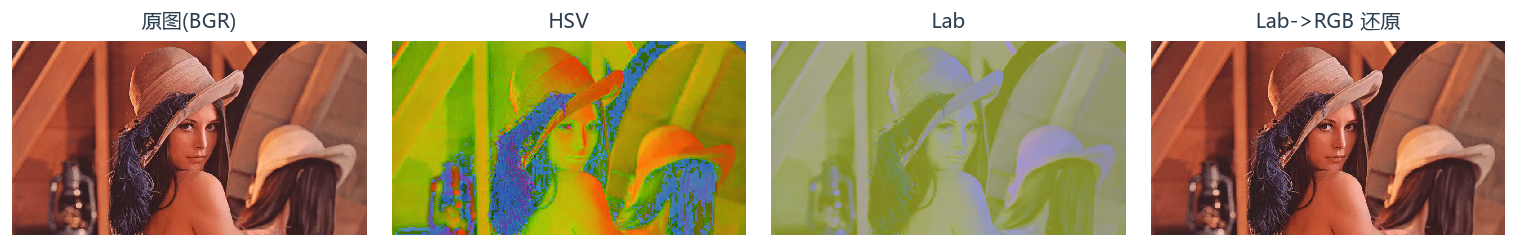

In [3]:
# 读取彩色图像，手写 RGB -> HSV / Lab，并保存各通道
img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
assert img is not None, "读取 lena.jpeg 失败"

hsv_m = rgb_to_hsv_manual(img)
lab_m = rgb_to_lab_manual(img)

# 各通道单独保存
for name, channel in [("h", 0), ("s", 1), ("v", 2)]:
    cv_imwrite(f"{name}_channel.jpg", hsv_m[:, :, channel])
for name, channel in [("l", 0), ("a", 1), ("b", 2)]:
    cv_imwrite(f"{name}_channel.jpg", lab_m[:, :, channel])

# 从保存的单通道"图像"读回并重组，转换回 RGB
h_ch = cv_imread("h_channel.jpg", cv2.IMREAD_GRAYSCALE)
s_ch = cv_imread("s_channel.jpg", cv2.IMREAD_GRAYSCALE)
v_ch = cv_imread("v_channel.jpg", cv2.IMREAD_GRAYSCALE)
hsv_rebuilt = cv2.merge([h_ch, s_ch, v_ch])
restored_from_hsv = hsv_to_rgb_manual(hsv_rebuilt)

l_ch = cv_imread("l_channel.jpg", cv2.IMREAD_GRAYSCALE)
a_ch = cv_imread("a_channel.jpg", cv2.IMREAD_GRAYSCALE)
b_ch = cv_imread("b_channel.jpg", cv2.IMREAD_GRAYSCALE)
lab_rebuilt = cv2.merge([l_ch, a_ch, b_ch])
restored_from_lab = lab_to_rgb_manual(lab_rebuilt)

# ---------- 与 OpenCV 对比验证 ----------
hsv_cv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab_cv = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
compare_results(hsv_m, hsv_cv, "RGB->HSV")
compare_results(lab_m, lab_cv, "RGB->Lab")
compare_results(restored_from_hsv, cv2.cvtColor(hsv_cv, cv2.COLOR_HSV2BGR), "HSV->RGB 还原")
compare_results(restored_from_lab, cv2.cvtColor(lab_cv, cv2.COLOR_Lab2BGR), "Lab->RGB 还原")

show_images([img, hsv_m, lab_m, restored_from_lab], ["原图(BGR)", "HSV", "Lab", "Lab->RGB 还原"], figsize=(13, 4))

findfont: Failed to find font weight medium, now using 400.


💡 HSV 三通道直观含义：
   H = 色调（什么颜色，红/橙/黄/绿/青/蓝/紫...）
   S = 饱和度（颜色鲜艳度 = 0 就是灰度，= 255 就是最鲜艳）
   V = 明度（整体亮度，0 全黑 255 最亮）


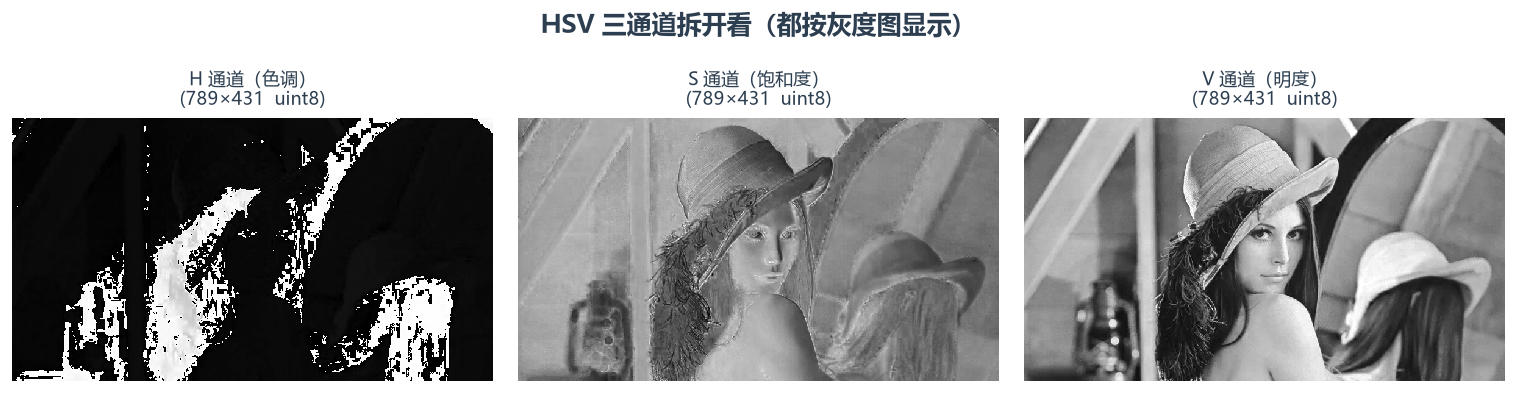


💡 Lab 三通道直观含义：
   L = 纯亮度信息（0 黑 / 100 白，等价于灰度图）
   a = 绿↔红 色轴（负值偏绿、正值偏红）
   b = 蓝↔黄 色轴（负值偏蓝、正值偏黄）


D:\CODE\Hands-On-Computer-Vision\utils.py:146: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Microsoft YaHei.
  plt.tight_layout(pad=padding, h_pad=1.5, w_pad=1.5)


D:\python\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


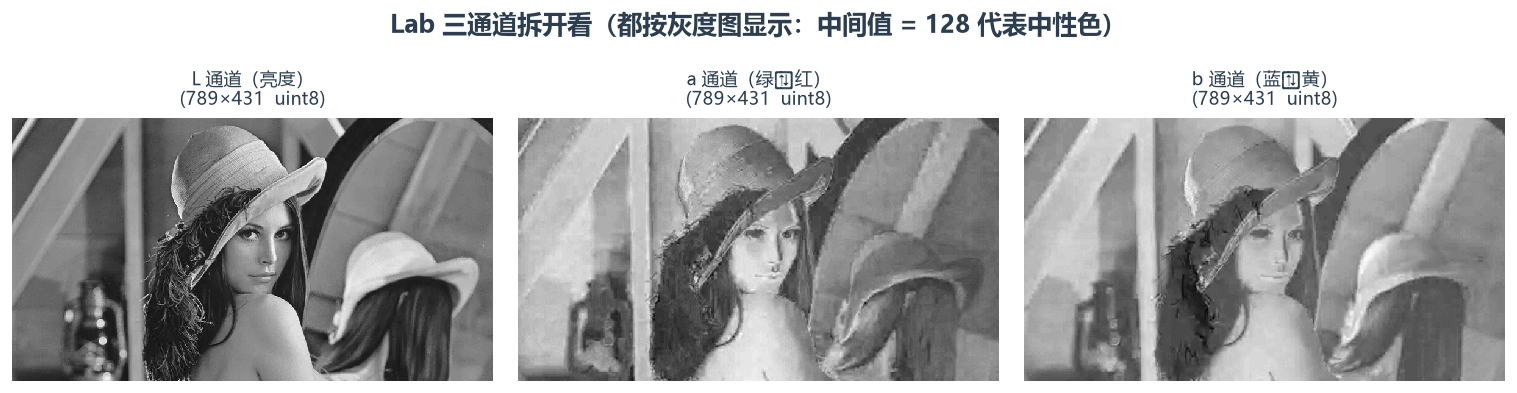

In [4]:
# ---------- 零基础：把 HSV 和 Lab 的各通道拆开看 ----------
print("💡 HSV 三通道直观含义：")
print("   H = 色调（什么颜色，红/橙/黄/绿/青/蓝/紫...）")
print("   S = 饱和度（颜色鲜艳度 = 0 就是灰度，= 255 就是最鲜艳）")
print("   V = 明度（整体亮度，0 全黑 255 最亮）")
show_images(
    [hsv_m[:, :, 0], hsv_m[:, :, 1], hsv_m[:, :, 2]],
    titles=["H 通道（色调）", "S 通道（饱和度）", "V 通道（明度）"],
    cmap="gray", suptitle="HSV 三通道拆开看（都按灰度图显示）",
    show_info=True, figsize=(13, 4)
)

print("\n💡 Lab 三通道直观含义：")
print("   L = 纯亮度信息（0 黑 / 100 白，等价于灰度图）")
print("   a = 绿↔红 色轴（负值偏绿、正值偏红）")
print("   b = 蓝↔黄 色轴（负值偏蓝、正值偏黄）")
show_images(
    [lab_m[:, :, 0], lab_m[:, :, 1], lab_m[:, :, 2]],
    titles=["L 通道（亮度）", "a 通道（绿↔红）", "b 通道（蓝↔黄）"],
    cmap="gray", suptitle="Lab 三通道拆开看（都按灰度图显示：中间值 = 128 代表中性色）",
    show_info=True, figsize=(13, 4)
)

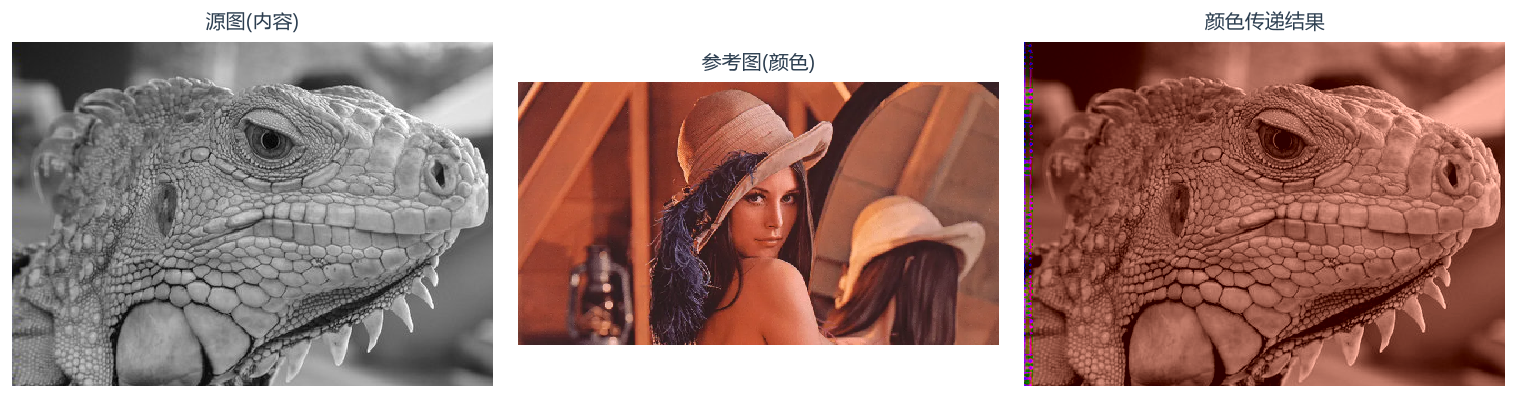

In [5]:
# 手写颜色传递：把 chong.png 的色彩迁移到 lena.jpeg 上
source = cv_imread("chong.png", cv2.IMREAD_COLOR)
target = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
source = rgba_to_bgr(source) if source.shape[2] == 4 else source

transferred = color_transfer_manual(source, target)
cv_imwrite("color_transferred.jpg", transferred)
show_images([source, target, transferred], ["源图(内容)", "参考图(颜色)", "颜色传递结果"], figsize=(13, 4))

## 四、结果与参数分析

- RGB→HSV / RGB→Lab 与 `cv2.cvtColor` 的 MAE 通常 < 1~2 个灰度级，差异来自取整方式与 Lab 的极值裁剪。
- HSV 更适合"按颜色抠图 / 调色"，Lab 的 a、b 通道与亮度解耦，更适合颜色传递。
- 颜色传递的效果取决于源图与参考图的内容分布：均值/标准差假设两图颜色呈**近似高斯分布**，对风景、人像等效果较好，对极端高对比图可能出现色偏。

**易错点**
1. `chong.png` 带 alpha 通道，务必先去掉 alpha 再参与转换。
2. 转换要在 `[0,1]` 浮点域进行，保存回 `uint8` 前裁剪并取整。
3. Lab 需要 D65 参考白与 sRGB 线性化，忽略线性化会导致与 OpenCV 结果偏差较大。

## 五、科研规范小结

1. **公式到代码一一对应**：每个转换公式都写成独立、可测试的函数，避免"大杂烩"。
2. **双向可逆校验**：RGB→HSV→RGB 的还原误差应很小，这比单纯目测更可靠。
3. **量化误差意识**：`uint8` 存储会引入取整误差，需用 `compare_results` 显式量化。
4. **通道拆分/重组**：HSV、Lab 各通道物理含义不同，单独保存便于调试与教学。

## 六、练习：手写 HSV 色彩筛选

**要求**：不调用 `cv2.inRange` / `cv2.cvtColor`，利用上面手写的 `rgb_to_hsv_manual` 写一个 `select_by_hue_manual(image, h_min, h_max, s_min, v_min)`，把指定色调范围的像素保留为白色、其余置黑，并保存掩膜。

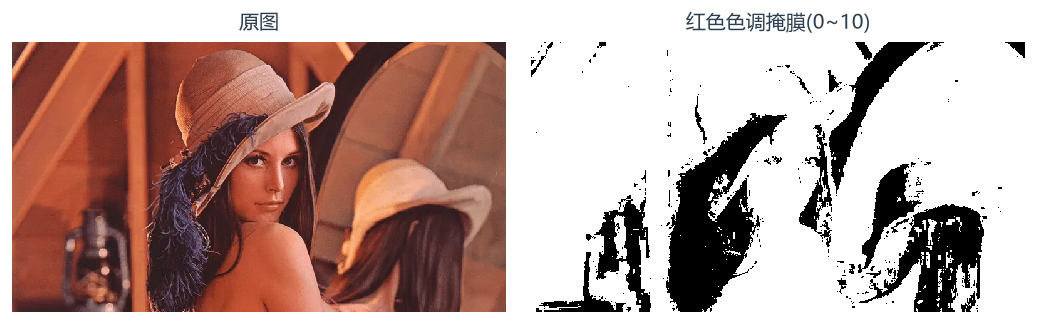

In [6]:
# ==================== 练习解决方案 ====================
def select_by_hue_manual(image, h_min, h_max, s_min=0, v_min=0):
    """手写 HSV 色彩筛选：返回二值掩膜（保留为 255）。"""
    hsv = rgb_to_hsv_manual(image)
    h, w, _ = hsv.shape
    mask = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            hh, ss, vv = (int(hsv[y, x, c]) for c in range(3))
            if h_min <= hh <= h_max and ss >= s_min and vv >= v_min:
                mask[y, x] = 255
    return mask

img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
mask = select_by_hue_manual(img, h_min=0, h_max=10, s_min=60, v_min=60)
cv_imwrite("hue_mask.jpg", mask)
show_images([img, mask], ["原图", "红色色调掩膜(0~10)"], figsize=(9, 4))

## 七、OpenCV 色彩空间 API 实战

> 以下内容参考《第4章 色彩空间类型转换》，使用 OpenCV 官方函数完成色彩空间转换、颜色标记、HSV 分量调整与 Alpha 通道操作。与前面"手写实现"互为对照。

### 7.1 类型转换函数 `cv2.cvtColor`

`dst = cv2.cvtColor(src, code[, dstCn])`

| 参数 | 说明 |
|------|------|
| `dst` | 输出图像，与原始输入图像具有同样的数据类型和深度 |
| `src` | 原始输入图像 |
| `code` | 色彩空间转换码（如 `cv2.COLOR_BGR2RGB`、`cv2.COLOR_BGR2HSV` 等）|
| `dstCn` | 目标图像的通道数，默认为 0，自动通过原始输入图像和 code 得到 |

#### GRAY 色彩空间

- Gray（灰度图像）通常指 8 位灰度图，具有 256 个灰度级，像素值范围 $[0, 255]$
- RGB GRAY：$\text{Gray} = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$
- GRAY RGB：$R = G = B = \text{Gray}$


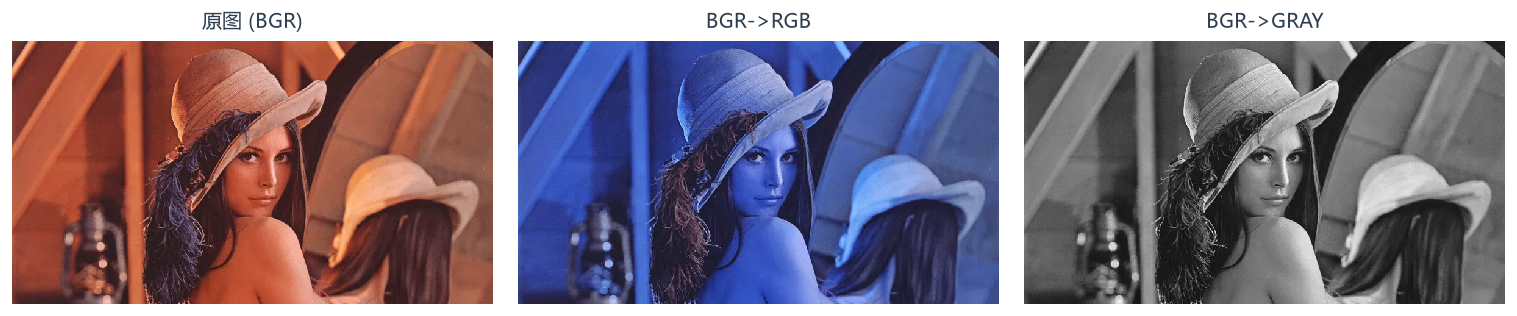

In [7]:
# cv2.cvtColor 基本用法：BGR <-> RGB / GRAY 转换
import cv2
import matplotlib.pyplot as plt

lena = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
assert lena is not None, "读取 lena.jpeg 失败"

rgb = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(lena, cv2.COLOR_BGR2GRAY)

show_images(
    [lena, rgb, gray],
    ["原图 (BGR)", "BGR->RGB", "BGR->GRAY"],
    figsize=(13, 4)
)

### 7.2 标记指定颜色 `cv2.inRange`

`dst = cv2.inRange(src, lowerb, upperb)`

| 参数 | 说明 |
|------|------|
| `dst` | 输出结果，大小和 src 一致；src 值在指定区间内则 dst 对应位置为 255，否则为 0 |
| `src` | 要检查的数组或图像 |
| `lowerb` | 范围下界 |
| `upperb` | 范围上界 |

#### HSV 空间中的颜色范围参考

| 颜色 | H 范围 (OpenCV) | S 范围 | V 范围 |
|------|-----------------|--------|--------|
| 蓝色 | $[110, 130]$ | $[100, 255]$ | $[100, 255]$ |
| 绿色 | $[50, 70]$ | $[100, 255]$ | $[100, 255]$ |
| 红色 | $[0, 10]$ | $[100, 255]$ | $[100, 255]$ |

> **注意**：OpenCV 中 HSV 的 H 通道范围为 $[0, 180)$（即真实色相值除以 2），S 和 V 通道范围为 $[0, 255]$。


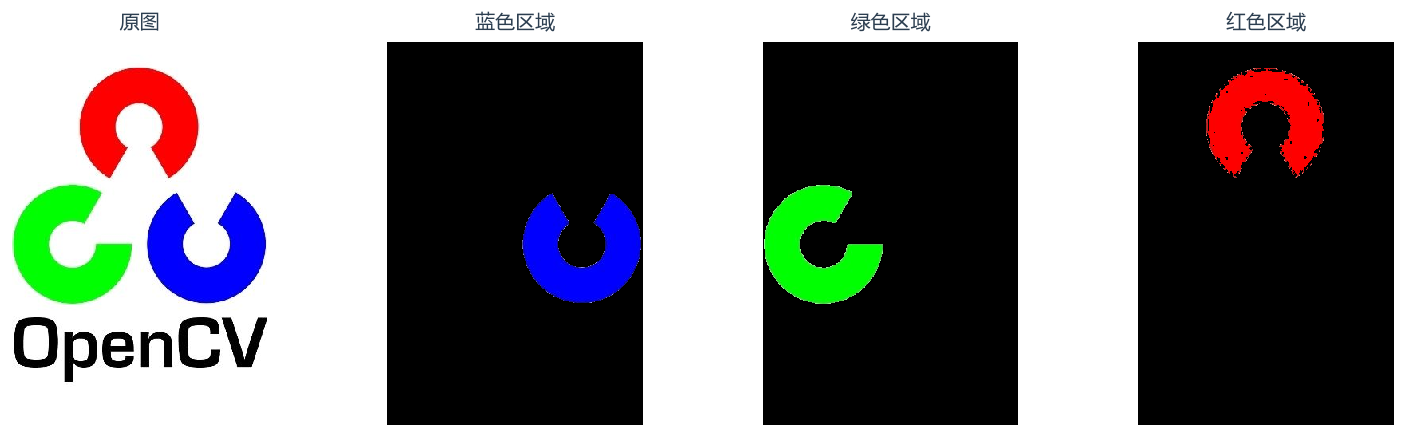

In [8]:
# 通过 inRange + 按位与操作，标记图像中的指定颜色区域
import numpy as np

opencv = cv_imread("opencv.jpg", cv2.IMREAD_COLOR)
assert opencv is not None, "读取 opencv.jpg 失败"
hsv = cv2.cvtColor(opencv, cv2.COLOR_BGR2HSV)

# ============= 指定蓝色值的范围 =============
minBlue = np.array([110, 100, 100])
maxBlue = np.array([130, 255, 255])
mask = cv2.inRange(hsv, minBlue, maxBlue)
blue = cv2.bitwise_and(opencv, opencv, mask=mask)

# ============= 指定绿色值的范围 =============
minGreen = np.array([50, 100, 100])
maxGreen = np.array([70, 255, 255])
mask = cv2.inRange(hsv, minGreen, maxGreen)
green = cv2.bitwise_and(opencv, opencv, mask=mask)

# ============= 指定红色值的范围 =============
minRed = np.array([0, 100, 100])
maxRed = np.array([10, 255, 255])
mask = cv2.inRange(hsv, minRed, maxRed)
red = cv2.bitwise_and(opencv, opencv, mask=mask)

show_images(
    [opencv, blue, green, red],
    ["原图", "蓝色区域", "绿色区域", "红色区域"],
    figsize=(13, 4)
)

### 7.3 调整 HSV 色彩空间的分量值

HSV 空间将"颜色"（H）、"鲜艳度"（S）与"明暗"（V）解耦，因此可以通过单独修改某个通道来改变图像的色调、饱和度或亮度。

- **H（色调）**：改变 H 可以实现"换色"效果
- **S（饱和度）**：S 越大颜色越鲜艳，S = 0 即为灰度图
- **V（明度）**：V 越大图像越亮，V = 255 为最亮


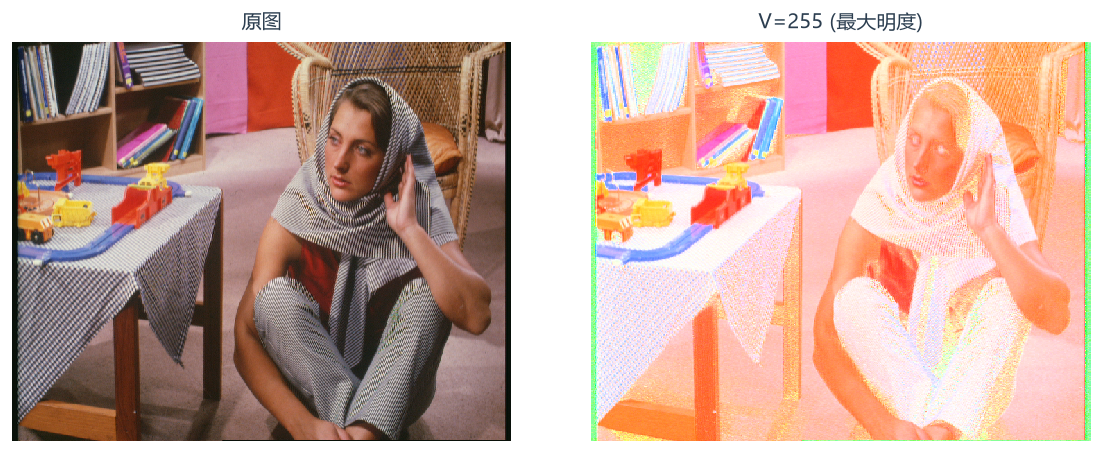

In [9]:
# 调整 HSV 中 V（明度）通道的值，观察图像变化
img = cv_imread("barbara.bmp", cv2.IMREAD_COLOR)
assert img is not None, "读取 barbara.bmp 失败"

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# 将 V 通道全部设为 255（最大亮度）
v[:, :] = 255
newHSV = cv2.merge([h, s, v])
art = cv2.cvtColor(newHSV, cv2.COLOR_HSV2BGR)

show_images(
    [img, art],
    ["原图", "V=255 (最大明度)"],
    figsize=(10, 4)
)

### 7.4 Alpha 通道（RGBA 色彩空间）

在 RGB 色彩空间基础上，增加一个 $A$ 通道（alpha），表示透明度，这种色彩空间称为 **RGBA** 色彩空间。

| Alpha 值 | 效果 |
|----------|------|
| $A = 0$ | 完全透明 |
| $A = 125$ | 半透明 |
| $A = 255$ | 完全不透明 |

PNG 图像是一种典型的 4 通道（RGBA）图像。通过 `cv2.COLOR_BGR2BGRA` 可将 3 通道 BGR 图像扩展为 4 通道 BGRA。


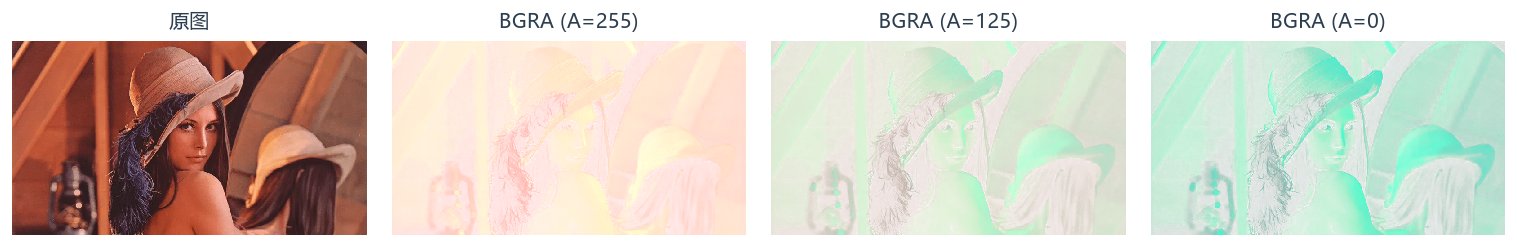

注意: matplotlib 无法显示 Alpha 透明通道，需在文件管理器中查看保存的 PNG 文件以观察透明效果。


In [10]:
# Alpha 通道操作：创建不同透明度的 BGRA 图像并保存为 PNG
img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
assert img is not None, "读取 lena.jpeg 失败"

bgra = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
b, g, r, a = cv2.split(bgra)

# alpha = 125，半透明
a[:, :] = 125
bgra125 = cv2.merge([b, g, r, a])

# alpha = 0，完全透明
a[:, :] = 0
bgra0 = cv2.merge([b, g, r, a])

# 保存为 PNG（PNG 支持 alpha 通道）
cv_imwrite("bgra.png", bgra)
cv_imwrite("bgra125.png", bgra125)
cv_imwrite("bgra0.png", bgra0)

# matplotlib 不显示 Alpha 透明通道，这里用 BGR->RGB 展示三通道效果
show_images(
    [img, bgra, bgra125, bgra0],
    ["原图", "BGRA (A=255)", "BGRA (A=125)", "BGRA (A=0)"],
    figsize=(13, 4)
)
print("注意: matplotlib 无法显示 Alpha 透明通道，需在文件管理器中查看保存的 PNG 文件以观察透明效果。")

### 7.5 小结：OpenCV API vs 手写实现

| 对比维度 | OpenCV API (`cvtColor` / `inRange`) | 手写实现 |
|----------|-----------------------------------|----------|
| **速度** | 底层 C++ 实现，支持 SIMD 加速，极快 | Python 循环，速度慢（约慢 100~1000 倍）|
| **精度** | 经过工业级验证，精度高 | 取决于实现细节，可能有取整误差 |
| **灵活性** | 固定的转换码，不支持自定义变换 | 可自由修改公式、插入中间步骤 |
| **教学价值** | "黑盒"调用，不便理解原理 | 公式到代码一一对应，深入理解 |
| **适用场景** | 工程项目、生产环境 | 学习、研究、自定义算法原型 |

> **最佳实践**：学习阶段先手写理解原理，工程实践中用 OpenCV API 保证性能和可靠性。